In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False

model_big = joblib.load('100people_score_model.pkl')
df_big = pd.read_csv("data_big.csv")

In [2]:
X_big = df_big[['age' , 'hours']]
y_big = df_big['score']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_big, y_big, test_size=0.2, random_state=42)

In [3]:
# hidden_layer_sizes=(10, 10) 代表有兩層大腦細胞，每層 10 個
nn_model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=10000, random_state=42)
nn_model.fit(X_train_b, y_train_b)

print(f"神經網路訓練集分數: {nn_model.score(X_train_b, y_train_b):.4f}")
print(f"神經網路測試集分數: {nn_model.score(X_test_b, y_test_b):.4f}")

神經網路訓練集分數: 0.9816
神經網路測試集分數: 0.9819


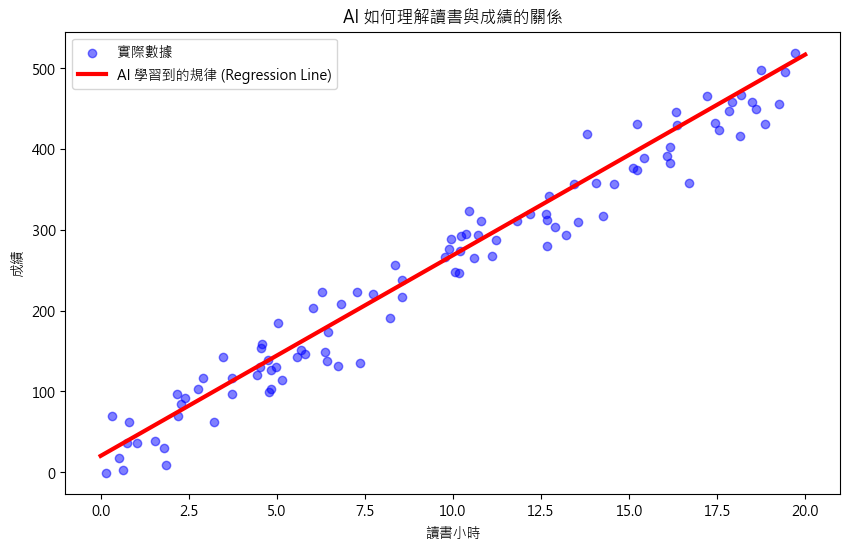

In [4]:
hours_range = np.linspace(0, 20, 100).reshape(-1, 1)

mock_input = pd.DataFrame({"age": [35]*100, "hours": hours_range.flatten()})

predicted_line = nn_model.predict(mock_input)

plt.figure(figsize=(10, 6))
plt.scatter(df_big['hours'], df_big['score'], color='blue', alpha=0.5, label='實際數據')
plt.plot(hours_range, predicted_line, color='red', linewidth=3, label='AI 學習到的規律 (Regression Line)')

plt.title('AI 如何理解讀書與成績的關係')
plt.xlabel('讀書小時')
plt.ylabel('成績')
plt.legend()
plt.show()

In [ ]:
np.random.seed(42)
ages = np.random.randint(10, 81, size=100)
hours = np.random.uniform(0, 20, size=100)

# 規律：分數 = (小時的開根號 * 80) - 年齡 + 隨機誤差
scores_curve = (np.sqrt(hours) * 80) - (ages * 1) + np.random.normal(50, 10, size=100)

df_curve = pd.DataFrame({'age': ages, 'hours': hours, 'score': scores_curve})

# 用神經網路重新訓練
X_c = df_curve[['age', 'hours']]
y_c = df_curve['score']
nn_curve = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=5000, random_state=42)
nn_curve.fit(X_c, y_c)

,loss,'squared_error'
,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,5000
,shuffle,True


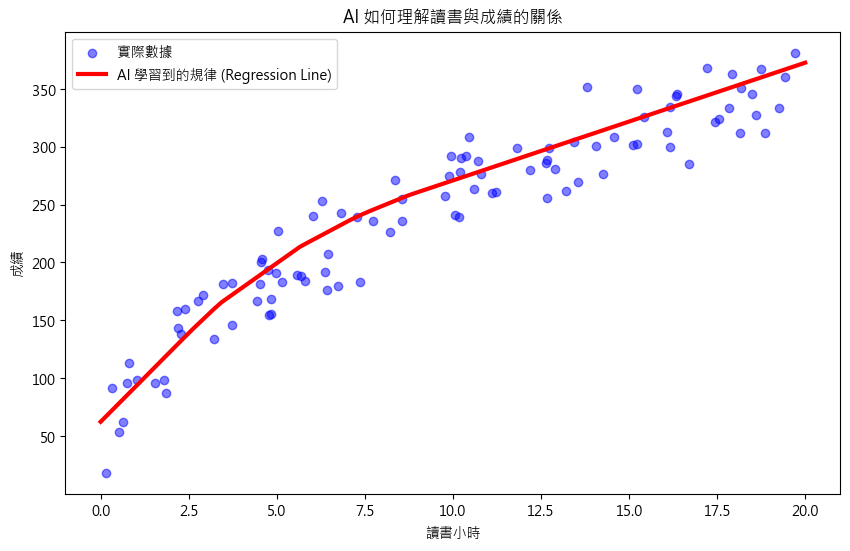

In [6]:
hours_range = np.linspace(0, 20, 100).reshape(-1, 1)

mock_input = pd.DataFrame({"age": [35]*100, "hours": hours_range.flatten()})

predicted_line = nn_curve.predict(mock_input)

plt.figure(figsize=(10, 6))
plt.scatter(df_curve['hours'], df_curve['score'], color='blue', alpha=0.5, label='實際數據')
plt.plot(hours_range, predicted_line, color='red', linewidth=3, label='AI 學習到的規律 (Regression Line)')

plt.title('AI 如何理解讀書與成績的關係')
plt.xlabel('讀書小時')
plt.ylabel('成績')
plt.legend()
plt.show()